# DLW Datathon 2026, Track 2: Intelligent Financial Fraud Detection

**Team:** TEAM_NAME

**Problem.** Out of 20,000 labelled card and transfer transactions, 353 (1.8%) are fraud. We must score 12,000
unlabelled transactions so that fraud is caught without flagging too many legitimate customers. The organisers
score PR-AUC, F1 and recall on a hidden test set that may contain different observations and edge cases.

**What that means for the modelling.**
- Accuracy is useless here: predicting "never fraud" is 98.2% accurate. We optimise ranking quality (PR-AUC) and then
  choose a decision threshold deliberately, as a business trade-off between missed fraud and false alarms.
- With only 353 positives, every estimate is noisy. We use repeated stratified cross-validation and prefer small,
  regularised models over flexible ones that memorise the few fraud rows.
- The test set has twice the share of missing values of the training set. Missingness is treated as information and
  every model handles gaps natively, so the hidden "edge cases" do not crash or distort predictions.

**Result.** A soft-vote blend of a regularised logistic regression and a 3-leaf LightGBM reaches cross-validated
PR-AUC ~0.21 (about 12x the 0.018 of a random ranker) and ROC-AUC ~0.78. At the chosen threshold it flags about 3% of
transactions and catches about a third of fraud at roughly 1-in-5 precision. The honest ceiling of this dataset is
low: the signal in the given columns is weak, and we say so rather than over-fit to the leaderboard.

## 1. Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import FixedThresholdClassifier, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
SEED = 42
np.random.seed(SEED)
print("pandas", pd.__version__, "| lightgbm", lgb.__version__)

pandas 3.0.6 | lightgbm 4.7.0


## 2. Load the data

The two CSVs are found automatically: next to this notebook, in `data/`, in `Track 2 Dataset/`, in Colab's
`/content`, or wherever `DATA_DIR` / `DATATHON_INPUT_PATH` point. Nothing needs editing to run this notebook.

In [2]:
TRAIN_NAME, TEST_NAME = "Track 2 Training Dataset.csv", "Track 2 Testing Dataset.csv"

def find_file(name):
    roots = [os.environ.get("DATA_DIR"), ".", "data", "Track 2 Dataset", os.path.join("data", "Track 2 Dataset"),
             "/content", "/content/data", "/content/Track 2 Dataset", "/content/drive/MyDrive", ".."]
    for r in roots:
        if r and os.path.isfile(os.path.join(r, name)):
            return os.path.join(r, name)
    for root, _, files in os.walk("."):          # last resort: anywhere under the working directory
        if name in files:
            return os.path.join(root, name)
    raise FileNotFoundError(f"Could not find '{name}'. Put it next to this notebook or in a 'data' folder.")

TRAIN_PATH = find_file(TRAIN_NAME)
TEST_PATH = os.environ.get("DATATHON_INPUT_PATH") or find_file(TEST_NAME)
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
print("train:", TRAIN_PATH, train.shape, "| test:", TEST_PATH, test.shape)
print("fraud rate in training data:", round(train["fraud"].mean() * 100, 2), "%  (", int(train["fraud"].sum()), "fraud rows )")
train.head()

train: data/Track 2 Training Dataset.csv (20000, 12) | test: data/Track 2 Testing Dataset.csv (12000, 11)
fraud rate in training data: 1.76 %  ( 353 fraud rows )


,id,transaction_amount,transaction_hour,merchant_category,country,transaction_channel,transactions_last_24h,spend_last_24h,account_age,new_device,transactions_last_1h,fraud
0,FR016993,55.03,16,retail,SG,ecommerce,27.0,1791.34,1192.0,0.0,5.0,0
1,FR002433,20.75,1,gaming,SG,mobile_app,3.0,217.96,3073.0,0.0,0.0,0
2,FR009253,21.51,9,entertainment,SG,mobile_app,3.0,62.71,985.0,0.0,0.0,0
3,FR004881,813.98,16,utilities,GB,mobile_app,2.0,110.48,653.0,0.0,1.0,0
4,FR014830,13.54,20,food_delivery,SG,card_present,4.0,114.98,79.0,0.0,0.0,0


## 3. Exploratory data analysis

Three questions: how imbalanced is it, what is missing, and which columns actually separate fraud from normal.

In [3]:
print("Missing values, training vs test (share of rows):")
missing = pd.DataFrame({"train %": (train.isna().mean() * 100).round(2), "test %": (test.isna().mean() * 100).round(2)})
print(missing[missing["train %"] + missing["test %"] > 0].to_string())
print("\nThe test set has roughly twice the missing rate. Missing must be handled, never dropped.")

Missing values, training vs test (share of rows):
                       train %  test %
account_age               0.68    2.20
country                   0.53    2.23
merchant_category         0.56    2.16
new_device                0.62    2.44
spend_last_24h            0.66    2.22
transaction_channel       0.62    2.37
transactions_last_1h      0.71    2.04
transactions_last_24h     0.80    2.44

The test set has roughly twice the missing rate. Missing must be handled, never dropped.


In [4]:
# Fraud rate by each categorical field. A flat table means the field carries little signal.
for c in ["new_device", "merchant_category", "transaction_channel", "country"]:
    g = train.groupby(c, dropna=False)["fraud"].agg(rate="mean", n="count").sort_values("rate", ascending=False)
    g["rate"] = (g["rate"] * 100).round(2)
    print(f"\n{c}: fraud rate (%) and count"); print(g.to_string())


new_device: fraud rate (%) and count
            rate      n
new_device             
1.0         7.50   1800
0.0         1.21  18076
NaN         0.00    124

merchant_category: fraud rate (%) and count
                   rate     n
merchant_category            
luxury             5.29   586
cash_transfer      4.74  1498
electronics        3.94  1524
travel             2.38  1094
food_delivery      1.65  2304
gaming             1.57  1339
utilities          1.20  1581
entertainment      1.00  1407
retail             0.96  2601
transport          0.88  2387
grocery            0.76  3566
NaN                0.00   113

transaction_channel: fraud rate (%) and count
                     rate     n
transaction_channel            
NaN                  3.25   123
bank_transfer        2.84  2009
ecommerce            2.40  5507
mobile_app           1.68  5172
card_present         1.02  7189

country: fraud rate (%) and count
         rate      n
country             
ID       4.05    840
VN      

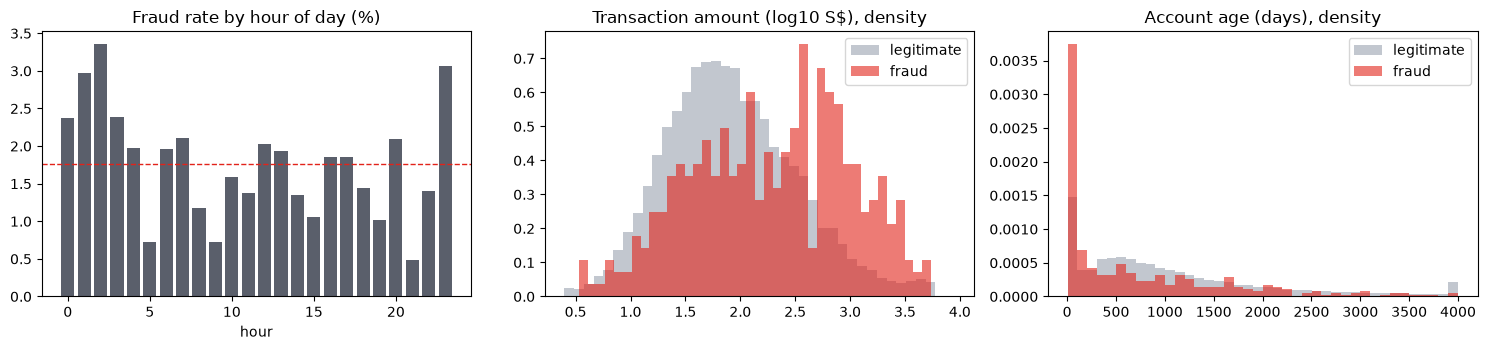

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
by_hour = train.groupby("transaction_hour")["fraud"].mean() * 100
axes[0].bar(by_hour.index, by_hour.values, color="#5a5f6b"); axes[0].axhline(train["fraud"].mean() * 100, color="#E2231A", ls="--", lw=1)
axes[0].set_title("Fraud rate by hour of day (%)"); axes[0].set_xlabel("hour")
for lab, col in [("legitimate", "#9aa2af"), ("fraud", "#E2231A")]:
    sub = train[train["fraud"] == (lab == "fraud")]
    axes[1].hist(np.log10(sub["transaction_amount"]), bins=40, density=True, alpha=0.6, label=lab, color=col)
axes[1].set_title("Transaction amount (log10 S$), density"); axes[1].legend()
for lab, col in [("legitimate", "#9aa2af"), ("fraud", "#E2231A")]:
    sub = train[train["fraud"] == (lab == "fraud")]
    axes[2].hist(sub["account_age"].dropna(), bins=40, density=True, alpha=0.6, label=lab, color=col)
axes[2].set_title("Account age (days), density"); axes[2].legend()
plt.tight_layout(); plt.show()

In [6]:
print("Medians, legitimate vs fraud:")
print(train.groupby("fraud")[["transaction_amount", "transactions_last_24h", "transactions_last_1h", "spend_last_24h", "account_age"]].median().round(1).T)

Medians, legitimate vs fraud:
fraud                      0      1
transaction_amount      74.3  224.3
transactions_last_24h    4.0    5.0
transactions_last_1h     1.0    1.0
spend_last_24h         214.5  662.8
account_age            796.0  335.5


**What the data says.**
- A **new device** is the single strongest flag: 7.5% fraud vs 1.2% on a known device.
- **Merchant category** matters: luxury (5.3%), cash transfer (4.7%) and electronics (3.9%) against grocery (0.8%).
- **Country**: every non-Singapore country is riskier than SG (1.3%), with Indonesia, Vietnam and the Philippines above 3.4%.
- **Channel**: bank transfer and e-commerce are riskier than card-present.
- **Time**: late night (23:00 to 03:00) carries about twice the base rate.
- **Behaviour**: fraud rows have larger amounts (median S$224 vs S$74), younger accounts (median 336 vs 796 days) and more
  activity in the last 24 hours and the last hour.
- Each effect is modest on its own. There is no column that identifies fraud by itself, so the model must combine
  many weak signals, and we should expect moderate scores whatever the model.

## 4. Cleaning and feature engineering

**Cleaning.** No duplicate ids, no impossible values (amounts from S$2.50 to S$9,000; hours 0 to 23). The only issue is
missing values in eight columns. We do not impute aggressively: tree models receive `NaN` as is, the logistic
regression gets a median fill, and every column gets a `*_missing` indicator so "the value was absent" is itself a
feature. Categorical gaps become their own `missing` level.

**Engineered features** (all computable from one row, so the same function runs at prediction time):

| Feature | Idea |
|---|---|
| `amount_log`, `account_age_log` | Heavy-tailed values on a sensible scale for the linear model |
| `amount_vs_recent_avg` | This payment relative to the account's average ticket in the last 24h: a jump is suspicious |
| `amount_share_of_24h` | How much of today's spend this one payment is |
| `burst_1h_share` | Share of the last 24h's transactions that happened in the last hour: a burst |
| `is_night`, `is_foreign`, `is_new_account`, `high_risk_category` | The EDA findings as explicit flags, which helps the linear model |
| `new_device_foreign`, `new_device_high_risk` | The two strongest signals combined |
| `*_missing` | Missingness indicators (the test set has twice as many gaps) |

In [7]:
CATEGORICAL = ["merchant_category", "country", "transaction_channel"]
NUMERIC_RAW = ["transaction_amount", "transaction_hour", "transactions_last_24h", "spend_last_24h",
               "account_age", "new_device", "transactions_last_1h"]
HIGH_RISK_CATEGORIES = {"luxury", "cash_transfer", "electronics", "travel"}

def make_features(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    for c in NUMERIC_RAW:
        out[c] = pd.to_numeric(df[c], errors="coerce")
    for c in NUMERIC_RAW + CATEGORICAL:
        out[f"{c}_missing"] = df[c].isna().astype(int)
    amt = out["transaction_amount"]
    out["amount_log"] = np.log1p(amt)
    avg_recent = out["spend_last_24h"] / out["transactions_last_24h"].replace(0, np.nan)
    out["amount_vs_recent_avg"] = amt / avg_recent.replace(0, np.nan)
    out["amount_share_of_24h"] = amt / (out["spend_last_24h"] + amt)
    out["burst_1h_share"] = out["transactions_last_1h"] / out["transactions_last_24h"].replace(0, np.nan)
    out["is_night"] = out["transaction_hour"].isin([23, 0, 1, 2, 3, 4]).astype(int)
    out["account_age_log"] = np.log1p(out["account_age"])
    out["is_new_account"] = (out["account_age"] < 90).astype(int)
    out["is_foreign"] = (df["country"].notna() & (df["country"] != "SG")).astype(int)
    out["high_risk_category"] = df["merchant_category"].isin(HIGH_RISK_CATEGORIES).astype(int)
    out["new_device_foreign"] = out["new_device"].fillna(0).astype(int) * out["is_foreign"]
    out["new_device_high_risk"] = out["new_device"].fillna(0).astype(int) * out["high_risk_category"]
    for c in CATEGORICAL:
        out[c] = df[c].fillna("missing").astype("category")
    return out

X = make_features(train); y = train["fraud"].values
X_test = make_features(test)
feature_names = list(X.columns)
num_cols = [c for c in feature_names if c not in CATEGORICAL]
pos_weight = (y == 0).sum() / (y == 1).sum()
print(len(feature_names), "features |", "positive weight", round(pos_weight, 1))

31 features | positive weight 55.7


## 5. Validation strategy

- **Stratified 5-fold cross-validation** (each fold keeps the 1.8% fraud rate), with out-of-fold probabilities for
  every training row, so all metrics below are on data the model did not see.
- **Primary metric: PR-AUC** (average precision). It measures how well fraud is ranked above legitimate rows across all
  thresholds and, unlike ROC-AUC, is not flattered by the 98% majority class.
- **F1 and recall** are reported at a threshold chosen on the out-of-fold predictions (section 7), never at the
  default 0.5, which is meaningless for an imbalanced problem.
- A **baseline** (logistic regression) comes first; anything more complex must beat it to earn its place.

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def best_f1(y_true, p):
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1 = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
    i = int(np.nanargmax(f1[:-1])); return f1[i], thr[i], rec[i], prec[i]

def evaluate(name, model, Xa, fit_kwargs=None):
    oof = cross_val_predict(model, Xa, y, cv=skf, method="predict_proba", params=fit_kwargs)[:, 1]
    f1, thr, rec, prec = best_f1(y, oof)
    return {"model": name, "PR-AUC": average_precision_score(y, oof), "ROC-AUC": roc_auc_score(y, oof),
            "best F1": f1, "recall @ best F1": rec, "precision @ best F1": prec, "threshold": thr}, oof

def logistic(cols, C=0.03):
    num = [c for c in cols if c not in CATEGORICAL]; cat = [c for c in cols if c in CATEGORICAL]
    pre = ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num),
                             ("cat", OneHotEncoder(handle_unknown="ignore"), cat)])
    return Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", C=C))])

def small_lgbm(num_leaves=3, n_estimators=200):
    return lgb.LGBMClassifier(n_estimators=n_estimators, learning_rate=0.02, num_leaves=num_leaves, min_child_samples=100,
                              subsample=0.7, subsample_freq=1, colsample_bytree=0.6, reg_lambda=5.0,
                              scale_pos_weight=pos_weight ** 0.5, random_state=SEED, verbose=-1)

## 6. Baseline and model comparison

We compare a linear baseline with gradient boosting, on raw columns and on the engineered set, and deliberately include
one "big" boosted model to show that flexibility hurts here.

In [9]:
RAW = NUMERIC_RAW + CATEGORICAL
results, oofs = [], {}
for name, model, cols in [
    ("Logistic regression, raw columns (baseline)", logistic(RAW), RAW),
    ("Logistic regression, engineered features", logistic(feature_names), feature_names),
    ("HistGradientBoosting, engineered (sklearn)", Pipeline([("pre", ColumnTransformer([("num", "passthrough", num_cols), ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL)])),
                                                             ("clf", HistGradientBoostingClassifier(learning_rate=0.05, max_iter=400, max_leaf_nodes=15, class_weight="balanced", random_state=SEED))]), feature_names),
    ("LightGBM, large (15 leaves, 600 trees)", lgb.LGBMClassifier(n_estimators=600, learning_rate=0.03, num_leaves=15, min_child_samples=40, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, scale_pos_weight=pos_weight ** 0.5, random_state=SEED, verbose=-1), feature_names),
    ("LightGBM, small (3 leaves, 200 trees)", small_lgbm(), feature_names),
]:
    r, oof = evaluate(name, model, X[cols]); results.append(r); oofs[name] = oof
comparison = pd.DataFrame(results).set_index("model").round(4)
comparison

,PR-AUC,ROC-AUC,best F1,recall @ best F1,precision @ best F1,threshold
model,,,,,,
"Logistic regression, raw columns (baseline)",0.1905,0.7723,0.2722,0.2040,0.4091,0.9086
"Logistic regression, engineered features",0.2013,0.7813,0.2883,0.2295,0.3876,0.9128
"HistGradientBoosting, engineered (sklearn)",0.1658,0.7518,0.2583,0.2210,0.3108,0.7873
"LightGBM, large (15 leaves, 600 trees)",0.1788,0.7330,0.2657,0.2040,0.3810,0.4356
"LightGBM, small (3 leaves, 200 trees)",0.2050,0.7847,0.2908,0.2550,0.3383,0.4493


**Takeaways.**
1. Engineered features help the linear model (PR-AUC 0.19 to 0.21): the interactions and ratios encode what the EDA found.
2. The large boosted model is **worse** than the baseline. With 353 positives, 15-leaf trees learn noise.
3. A deliberately small LightGBM (3 leaves, strong regularisation) matches the linear model while learning a few
   non-linear splits the linear model cannot. The two make different mistakes, which is exactly when a blend helps.

## 7. Final model: a blend, and a deliberate threshold

**Model.** A soft-vote average of (a) the regularised logistic regression and (b) the small LightGBM. Both are standard
scikit-learn / LightGBM estimators, so the blend is one `VotingClassifier` that loads anywhere with `joblib`.

**Threshold.** The default 0.5 is arbitrary. The problem statement asks for two things at once: catch fraud, and do not
disrupt legitimate customers. We choose the threshold that maximises **F-beta with beta = 1.5**, weighting recall a
little above precision because a missed fraud usually costs more than a false alarm that a customer confirms with one
tap. The table shows the trade-off so the operating point can be moved with one number.

In [10]:
def build_final():
    return VotingClassifier([("logistic", logistic(feature_names)), ("lightgbm", small_lgbm())], voting="soft", weights=[1, 1])

oof_final = cross_val_predict(build_final(), X, y, cv=skf, method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y, oof_final)
rows = []
for beta in [1.0, 1.5, 2.0]:
    fb = (1 + beta ** 2) * prec * rec / np.clip(beta ** 2 * prec + rec, 1e-9, None); i = int(np.nanargmax(fb[:-1]))
    rows.append({"rule": f"maximise F{beta:g}", "threshold": thr[i], "precision": prec[i], "recall": rec[i],
                 "F1": 2 * prec[i] * rec[i] / (prec[i] + rec[i]), "% of transactions flagged": (oof_final >= thr[i]).mean() * 100})
for t in [0.5, 0.6]:
    p = oof_final >= t; rows.append({"rule": f"fixed {t}", "threshold": t, "precision": precision_score(y, p), "recall": recall_score(y, p),
                                      "F1": f1_score(y, p), "% of transactions flagged": p.mean() * 100})
tradeoff = pd.DataFrame(rows).round(3)
BETA = 1.5
fb = (1 + BETA ** 2) * prec * rec / np.clip(BETA ** 2 * prec + rec, 1e-9, None); THRESHOLD = float(thr[int(np.nanargmax(fb[:-1]))])
print("Cross-validated PR-AUC:", round(average_precision_score(y, oof_final), 4), "| ROC-AUC:", round(roc_auc_score(y, oof_final), 4))
print("Chosen threshold:", round(THRESHOLD, 3))
tradeoff

Cross-validated PR-AUC: 0.2064 | ROC-AUC: 0.7848
Chosen threshold: 0.554


,rule,threshold,precision,recall,F1,% of transactions flagged
0,maximise F1,0.670,0.352,0.246,0.290,1.235
1,maximise F1.5,0.554,0.197,0.343,0.250,3.075
2,maximise F2,0.538,0.182,0.357,0.241,3.460
3,fixed 0.5,0.500,0.147,0.382,0.213,4.585
4,fixed 0.6,0.600,0.235,0.283,0.257,2.125


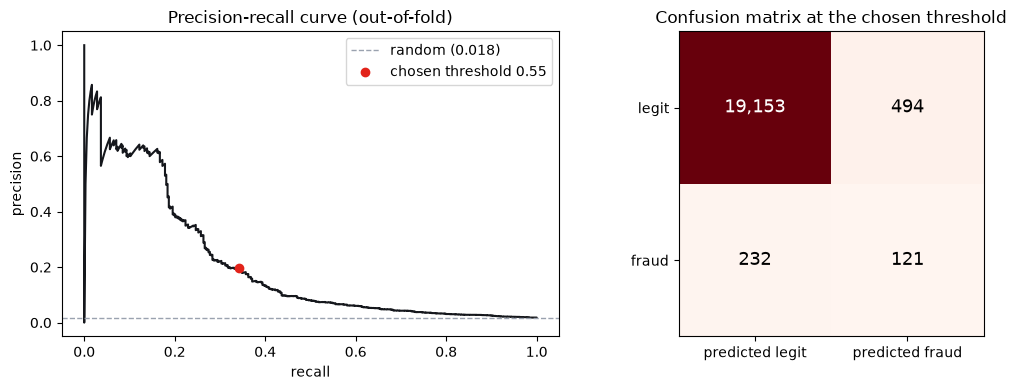

At the chosen threshold: 121 fraud caught, 232 missed, 494 false alarms out of 19,647 legitimate (2.51% of customers disturbed).


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(rec, prec, color="#15171C"); axes[0].axhline(y.mean(), color="#9aa2af", ls="--", lw=1, label=f"random ({y.mean():.3f})")
j = int(np.searchsorted(thr, THRESHOLD)); axes[0].scatter([rec[j]], [prec[j]], color="#E2231A", zorder=3, label=f"chosen threshold {THRESHOLD:.2f}")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision"); axes[0].set_title("Precision-recall curve (out-of-fold)"); axes[0].legend()
cm = confusion_matrix(y, oof_final >= THRESHOLD)
axes[1].imshow(cm, cmap="Reds"); axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1]); axes[1].set_xticklabels(["predicted legit", "predicted fraud"]); axes[1].set_yticklabels(["legit", "fraud"])
for (a, b), v in np.ndenumerate(cm): axes[1].text(b, a, f"{v:,}", ha="center", va="center", color="black" if v < cm.max() / 2 else "white", fontsize=13)
axes[1].set_title("Confusion matrix at the chosen threshold"); plt.tight_layout(); plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"At the chosen threshold: {tp} fraud caught, {fn} missed, {fp} false alarms out of {tn + fp:,} legitimate ({fp / (tn + fp) * 100:.2f}% of customers disturbed).")

## 8. What the model learned

Two views: the logistic regression's largest standardised coefficients (direction and size) and LightGBM's split gains.
Both should agree with the EDA; if they did not, something would be wrong.

In [12]:
final_cv = build_final().fit(X, y)
lr_pipe = final_cv.named_estimators_["logistic"]
names = list(lr_pipe.named_steps["pre"].get_feature_names_out())
coefs = pd.Series(lr_pipe.named_steps["clf"].coef_[0], index=[n.split("__", 1)[1] for n in names]).sort_values()
print("Logistic regression: strongest pushes towards FRAUD"); print(coefs.tail(8).round(3).to_string())
print("\nStrongest pushes towards LEGITIMATE"); print(coefs.head(6).round(3).to_string())
gbm = final_cv.named_estimators_["lightgbm"]
imp = pd.Series(gbm.booster_.feature_importance("gain"), index=feature_names).sort_values(ascending=False)
print("\nLightGBM: top features by split gain"); print((imp.head(10) / imp.sum() * 100).round(1).astype(str).add("%").to_string())

Logistic regression: strongest pushes towards FRAUD
merchant_category_luxury           0.222
is_night                           0.225
country_JP                         0.325
merchant_category_food_delivery    0.334
high_risk_category                 0.337
new_device                         0.341
country_GB                         0.368
country_ID                         0.609

Strongest pushes towards LEGITIMATE
country_MY                         -0.682
country_TH                         -0.459
transaction_channel_card_present   -0.363
merchant_category_retail           -0.316
new_device_missing                 -0.311
merchant_category_missing          -0.286

LightGBM: top features by split gain
new_device               17.4%
new_device_foreign       13.6%
transaction_amount        9.9%
transactions_last_1h      7.8%
transactions_last_24h     7.7%
account_age               6.5%
merchant_category         5.5%
high_risk_category        5.4%
account_age_log           5.0%
spend_last_24h

Both models lean on the same things the EDA surfaced: new device (especially abroad or in a high-risk category),
amount, account age, country, merchant category, and bursts of activity. Nothing surprising, which is reassuring:
the model is not exploiting an artefact.

## 9. Train on everything, save the model, predict the test set

Saved in the format from the handbook: `joblib.dump((model, feature_names), "model.pkl")`. The threshold is baked
into the object with `FixedThresholdClassifier`, so `model.predict()` applies our operating point and
`model.predict_proba()` gives the ranking score for PR-AUC.

In [13]:
final_model = FixedThresholdClassifier(build_final(), threshold=THRESHOLD, response_method="predict_proba").fit(X, y)
joblib.dump((final_model, feature_names), "model.pkl")

model, features = joblib.load("model.pkl")
X_test_f = make_features(test)[features]
test_proba = model.predict_proba(X_test_f)[:, 1]
test_pred = model.predict(X_test_f).astype(int)
assert len(test_pred) == len(test) and set(np.unique(test_pred)) <= {0, 1}
print(f"Flagged {test_pred.sum()} of {len(test_pred)} test transactions ({test_pred.mean() * 100:.2f}%)")

TEAM = "TEAM_NAME"
pd.DataFrame({"prediction": test_pred}).to_csv(f"{TEAM}_Datathon 2026_Track 2_Prediction.csv", index=False)
pd.DataFrame({"prediction": test_proba.round(6)}).to_csv(f"{TEAM}_Datathon 2026_Track 2_Prediction_probabilities.csv", index=False)
pd.DataFrame({"id": test["id"], "fraud_probability": test_proba.round(6), "prediction": test_pred}).to_csv(f"{TEAM}_Datathon 2026_Track 2_Prediction_with_ids.csv", index=False)
print("Saved model.pkl and the prediction files.")

Flagged 533 of 12000 test transactions (4.44%)
Saved model.pkl and the prediction files.


## 10. Assumptions, limitations and what we would do next

**Assumptions.**
- The hidden test set comes from the same process as the training set (same columns, similar fraud rate). We
  guarded against the stated "edge cases" by handling missing values natively and clipping nothing that could appear
  at larger scale, but a very different fraud rate would move the ideal threshold.
- Each row is independent. There is no customer or card id, so we cannot build per-customer history beyond the
  24-hour and 1-hour counts the data already gives.
- The behavioural columns (`transactions_last_24h`, `spend_last_24h`) were computed before the transaction, not
  after, so they are legitimate inputs and not leakage.

**Limitations.**
- The signal is weak: PR-AUC about 0.21 means about one in five of our top-ranked flags is real fraud. That is a
  property of the columns available, not of the model; every family we tried lands in the same band.
- 353 positives make the threshold itself uncertain (plus or minus a few points of recall between folds).
- The blend is only as interpretable as its parts; we report both parts' drivers above.

**Next steps, in order of expected value.**
1. Customer- or card-level identifiers would allow true behavioural baselines (typical hour, typical merchant, device
   history), which is where production fraud systems get most of their lift.
2. Cost-sensitive thresholding with real numbers: average fraud loss versus the cost of a confirmation message.
3. Calibrate the probabilities (isotonic) so the score can drive a tiered response: silent allow, confirm by SMS,
   block.
4. Monitor drift on the missingness rate and the country mix, both of which already differ between train and test.

## Appendix: reproducing and scoring from the saved model

Run from a clean environment with `pip install -r requirements.txt`, then execute this notebook top to bottom.
The cell below is the handbook's scoring step on its own: load `model.pkl`, rebuild the features with the same
function, predict. `make_features` must be identical to the one in section 4.

In [14]:
model, features = joblib.load("model.pkl")
input_path = os.environ.get("DATATHON_INPUT_PATH") or TEST_PATH
scoring_df = pd.read_csv(input_path)
preds = model.predict(make_features(scoring_df)[features]).astype(int)
print("rows:", len(preds), "| flagged:", int(preds.sum()))

rows: 12000 | flagged: 533
